## Welcome to the basic neural network tutorial!
The following notebook is designed to walk through the process of building and training your first scikit based algorithm using the standalone MaCh3 python utilities!

If you're writing scripts this is encapsulate in the objects in `MaCh3PythonUtils/config_reader` however this guide aims to break apart the process of writing the code for yourself!

The first step is to load in a MaCh3 MCMC fit as input file. This is done using the ChainHandler class!

In [1]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory
#from sklearn.model_selection import LearningCurveDisplay
from sklearn.model_selection import RandomizedSearchCV

# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import random as rand
import os
import pandas as pd
#import gdown

Using mps device

In [2]:

#file_url="https://drive.google.com/file/d/1iE6xFhn3BH_HnLUfQ7KFGy2wfeH52Rwf/view?usp=sharing"




path_NoAd_T2K= Path("../models/demo_files 2/NoAdapt/T2K")
path_NoAd_Nova= Path('../models/demo_files 2/NoAdapt/NOvA')
path_Ad_T2K= Path('../models/demo_files 2/Adapt/T2K')
path_Ad_Nova= Path('../models/demo_files 2/Adapt/NOvA')

NAD_T2K=[f"{path_NoAd_T2K}/{x}" for x in os.listdir(path_NoAd_T2K)] 
NAD_Nova=[f'{path_NoAd_Nova}/{y}' for y in os.listdir(path_NoAd_Nova)]
AD_T2K=[f'{path_Ad_T2K}/{z}' for z in os.listdir(path_Ad_T2K)]
AD_Nova=[f'{path_Ad_Nova}/{a}' for a in os.listdir(path_Ad_Nova)]

print(NAD_T2K)
print(NAD_Nova)
print(AD_T2K)
print(AD_Nova)


fitting_label = "ID"
paths = [NAD_T2K, NAD_Nova, AD_T2K, AD_Nova]
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

TEMP_NAD_T2K_list = []
TEMP_NAD_Nova_list = []
TEMP_AD_T2K_list = []
TEMP_AD_Nova_list = []

for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        chain_handler.ignore_plots(["xsec_20", "xsec_19"])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == NAD_T2K:
            TEMP_NAD_T2K_list.append(chain_handler)
        elif lm == NAD_Nova:
            TEMP_NAD_Nova_list.append(chain_handler)
        elif lm == AD_T2K:
            TEMP_AD_T2K_list.append(chain_handler)
        elif lm == AD_Nova:
            TEMP_AD_Nova_list.append(chain_handler)


NAD_T2K_data = TEMP_NAD_T2K_list[0]
NAD_T2K_data.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

NAD_Nova_data = TEMP_NAD_Nova_list[0]
NAD_Nova_data.ttree_array['ID']= 0

AD_T2K_data = TEMP_AD_T2K_list[0]
AD_T2K_data.ttree_array['ID']= 0

AD_Nova_data = TEMP_AD_Nova_list[0]
AD_Nova_data.ttree_array['ID']= 0


for id, chain in enumerate(TEMP_NAD_T2K_list[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    #chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
    NAD_T2K_data.ttree_array = pd.concat([NAD_T2K_data.ttree_array, chain.ttree_array])

for ida, chains in enumerate(TEMP_NAD_Nova_list[1:], start = 1): 
    #add ID to chain['id']
    chains.ttree_array['ID'] = ida
    chains.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chains.ttree_array))*1.2
    NAD_Nova_data.ttree_array = pd.concat([NAD_Nova_data.ttree_array, chains.ttree_array])

for idb, chainss in enumerate(TEMP_AD_T2K_list[1:], start = 1): 
    #add ID to chain['id']
    chainss.ttree_array['ID'] = idb
    #chainss.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chainss.ttree_array))*1.2
    AD_T2K_data.ttree_array = pd.concat([AD_T2K_data.ttree_array, chainss.ttree_array])

for idc, chainsss in enumerate(TEMP_AD_Nova_list[1:], start = 1): 
    #add ID to chain['id']
    chainsss.ttree_array['ID'] = idc
    #chainsss.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chainsss.ttree_array))*1.2
    AD_Nova_data.ttree_array = pd.concat([AD_Nova_data.ttree_array, chainsss.ttree_array])

#from now on, the files that include out data that uis now usable are: NAD_T2K_data, NAD_Nova_data, AD_T2K_data, AD_Nova_data

print(NAD_T2K_data.ttree_array)

['../models/demo_files 2/NoAdapt/T2K/mcmc_NoAdapt_T2K_oct_fix_mo_fix.root', '../models/demo_files 2/NoAdapt/T2K/mcmc_NoAdapt_T2K_oct_fix_no_only.root', '../models/demo_files 2/NoAdapt/T2K/mcmc_NoAdapt_T2K_all_fixed.root', '../models/demo_files 2/NoAdapt/T2K/mcmc_NoAdapt_T2K_all_on.root']
['../models/demo_files 2/NoAdapt/NOvA/mcmc_NoAdapt_NOvA_oct_fix_no_only.root', '../models/demo_files 2/NoAdapt/NOvA/mcmc_NoAdapt_NOvA_oct_fix_mo_fix.root', '../models/demo_files 2/NoAdapt/NOvA/mcmc_NoAdapt_NOvA_all_on.root']
['../models/demo_files 2/Adapt/T2K/mcmc_Adapt_T2K_all_fixed.root', '../models/demo_files 2/Adapt/T2K/mcmc_Adapt_T2K_all_on.root', '../models/demo_files 2/Adapt/T2K/mcmc_Adapt_T2K_oct_fix_no_only.root', '../models/demo_files 2/Adapt/T2K/mcmc_Adapt_T2K_oct_fix_mo_fix.root']
['../models/demo_files 2/Adapt/NOvA/mcmc_Adapt_NOvA_oct_fix_mo_fix.root', '../models/demo_files 2/Adapt/NOvA/mcmc_Adapt_NOvA_oct_fix_no_only.root', '../models/demo_files 2/Adapt/NOvA/mcmc_Adapt_NOvA_all_on.root']


## Machine learning
Okay now we've done some very basic file manipulation, it's time for some machine learning!
All algorithms use the same common `MLFactory` interface so let's go about configuring it!

In [3]:
'''
print(NAD_T2K_data.ttree_array['ID'])

hist = NAD_T2K_data.ttree_array['delta_cp'][NAD_T2K_data.ttree_array['ID']==0].hist()
plt.show()
hist = NAD_T2K_data.ttree_array['delta_cp'][NAD_T2K_data.ttree_array['ID']==1] 

NAD_T2K_data.ttree_array.columns
'''

"\nprint(NAD_T2K_data.ttree_array['ID'])\n\nhist = NAD_T2K_data.ttree_array['delta_cp'][NAD_T2K_data.ttree_array['ID']==0].hist()\nplt.show()\nhist = NAD_T2K_data.ttree_array['delta_cp'][NAD_T2K_data.ttree_array['ID']==1] \n\nNAD_T2K_data.ttree_array.columns\n"

In [4]:
# First step we need to initialise the factory
from pathlib import Path

path_NoAd_T2K.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_NADT2K = MLFactory(NAD_T2K_data, fitting_label, f"{path_NoAd_T2K}.pdf")


path_NoAd_Nova.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_NADNova = MLFactory(NAD_Nova_data, fitting_label, f"{path_NoAd_Nova}.pdf")



path_Ad_T2K.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_ADT2K = MLFactory(AD_T2K_data, fitting_label, f"{path_Ad_T2K}.pdf")


path_Ad_Nova.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_ADNova = MLFactory(AD_Nova_data, fitting_label, f"{path_Ad_Nova}.pdf")



ID
ID
ID
ID


Now we need to define a model, for this demonstration we'll make a very simple BDT!

In [5]:
# Now we can make the model/ make the interface on which the model can train and test
from sklearn.metrics import log_loss


ml_model_NADT2K = ml_factory_NADT2K.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=50, verbose=2, max_leaf_nodes=30, early_stopping=True, n_iter_no_change= 10)
ml_model_NADT2K.set_training_test_set(0.5)


#ml_model_NADNova = ml_factory_NADNova.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=50, verbose=2, max_leaf_nodes=30)
#ml_model_NADNova.set_training_test_set(0.3)
'''
ml_model_ADT2K = ml_factory_ADT2K.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
ml_model_ADT2K.set_training_test_set(0.3)

ml_model_ADNova = ml_factory_ADNova.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
ml_model_ADNova.set_training_test_set(0.3)
'''

"\nml_model_ADT2K = ml_factory_ADT2K.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)\nml_model_ADT2K.set_training_test_set(0.3)\n\nml_model_ADNova = ml_factory_ADNova.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)\nml_model_ADNova.set_training_test_set(0.3)\n"

Training Model
Binning 0.599 GB of training data: 0.927 s
Binning 0.067 GB of validation data: 0.097 s
Fitting gradient boosted rounds:
[1/50] 4 trees, 120 leaves (30 on avg), max depth = 9, train loss: 1.31607, val loss: 1.31625, in 0.645s
[2/50] 4 trees, 120 leaves (30 on avg), max depth = 11, train loss: 1.25858, val loss: 1.25876, in 0.587s
[3/50] 4 trees, 120 leaves (30 on avg), max depth = 11, train loss: 1.21410, val loss: 1.21443, in 0.585s
[4/50] 4 trees, 120 leaves (30 on avg), max depth = 16, train loss: 1.17268, val loss: 1.17302, in 0.628s
[5/50] 4 trees, 120 leaves (30 on avg), max depth = 12, train loss: 1.13133, val loss: 1.13159, in 0.725s
[6/50] 4 trees, 120 leaves (30 on avg), max depth = 15, train loss: 1.09718, val loss: 1.09734, in 0.605s
[7/50] 4 trees, 120 leaves (30 on avg), max depth = 12, train loss: 1.06719, val loss: 1.06744, in 0.608s
[8/50] 4 trees, 120 leaves (30 on avg), max depth = 18, train loss: 1.03457, val loss: 1.03478, in 0.619s
[9/50] 4 trees, 1

Number of independent MCMCs: 4

Training Results!

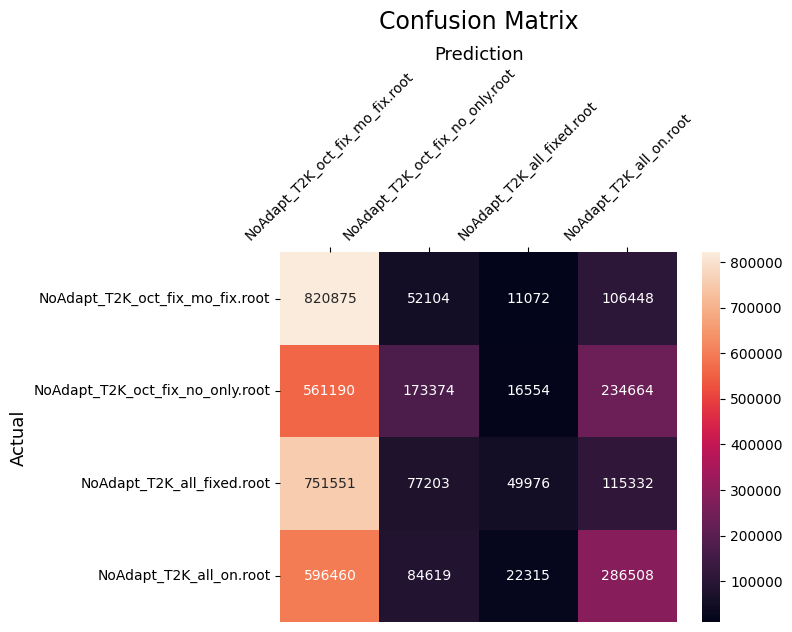

predictive accuracy: 0.3360228975732562

R*: 1.3440915902930248

=====

Testing Results!

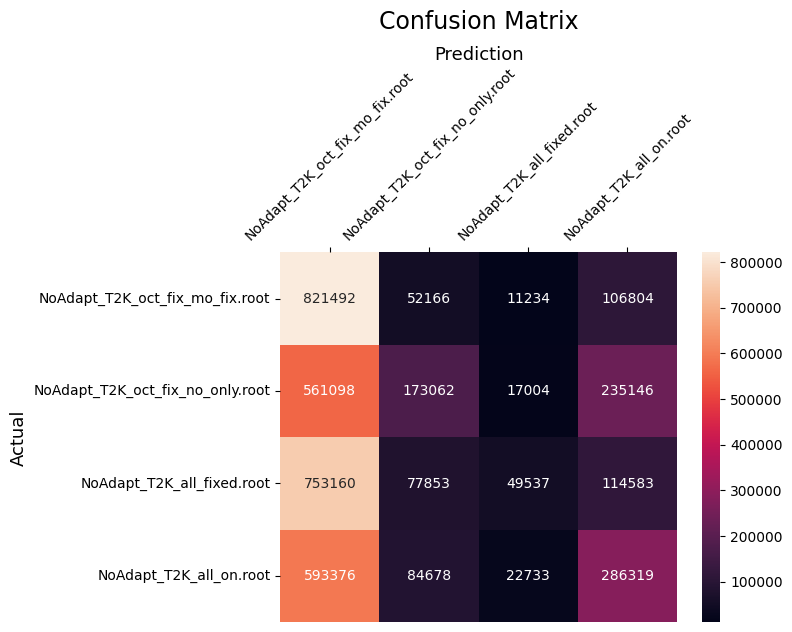

predictive accuracy: 0.3359413369627384

R*: 1.3437653478509537

=====

In [6]:

# Now we need to train our network
ml_model_NADT2K.train_model()

scikitmodel_NADT2K= ml_model_NADT2K.model
#scikitmodel_NADNova= ml_model_NADNova.model


ml_model_NADT2K.test_model_class(NAD_T2K, 'noadapt', 't2k', norm= False)

#ml_model_NADT2K.plot_loss(scikitmodel_NADT2K)


#LearningCurveDisplay.from_estimator( #prints out how well model learns when you give it a training size of 50, 80, 110 etx
#   scikitmodel_NADT2K, ml_model_NADT2K._training_data, ml_model_NADT2K._training_labels, train_sizes=[50000, 100000, 900000], cv=2) 


In [ ]:
#

dist={
        'learning_rate': np.arange(0.0001, 0.1, 0.0001 ),
        'max_leaf_nodes': [i for i in range(20, 700, 10)],
        'max_features': np.arange(0.1, 1, 0.1),
        'l2_regularization':[i for i in range(1, 20, 1)],
        'max_iter': [2] #changing this changes the actual number of iterations that th emodel makes
    }


clf = RandomizedSearchCV(estimator=scikitmodel_NADT2K, param_distributions=dist, cv=5, n_iter=2) #n_iter here is the number of times that RandomizedSearchCV is run PER iteration; 2 should be more than enough

search =clf.fit(ml_model_NADT2K.scale_data(ml_model_NADT2K._training_data), ml_model_NADT2K.scale_labels(ml_model_NADT2K._training_labels))
print(search.best_params_)



# code below is to plot the different values of R*
#maybe make the process in this block a Class??
#datapoints = 3
'''
ml_model_NADNova.test_model_class(NAD_Nova)
list_2 = ml_model_NADNova.getRStar_vals(NAD_Nova)# gets an array of R* values for chain list 2 (chain list 2 has 2 separate .ROOT files, chain 4 has 4 etc...)

ml_model_ADT2K.test_model_class(AD_T2K)
list_4 = ml_model_ADT2K.getRStar_vals(AD_T2K)

ml_model_ADNova.test_model_class(AD_Nova)
list_8 = ml_model_ADNova.getRStar_vals(AD_Nova)

def add_jitter(x, scale=0.2): #scales x-datapoints so that they don't overlap.
    return x + np.random.uniform(-scale, scale, size=len(x))

x1 = add_jitter([2.0]*datapoints)
x2= add_jitter([4.0]*datapoints)
x3= add_jitter([8.0]*datapoints)

#x4= [16.00000]*n
plt.scatter(x1,list_2, s=50, cmap= 'twilight', alpha= 0.5)
plt.scatter(x2,list_4, s=50, cmap= 'twilight', alpha= 0.5)
plt.scatter(x3,list_8, s=50, cmap= 'twilight', alpha= 0.5)

plt.xticks([2, 4, 8, 16], ['2', '4', '8', '16'])
plt.yticks([1.0, 1.2, 1.4], ['1.0', '1.2', '1.4'])
plt.title('Sensitivity to number of chains')
plt.xlabel('Number of Chains')
plt.ylabel('R* Value')

#plt.scatter(x3,list_8)
#plt.scatter(x4,list_16)
plt.show()


'''

Binning 0.479 GB of training data: 0.842 s
Binning 0.053 GB of validation data: 0.078 s
Fitting gradient boosted rounds:
[1/2] 4 trees, 1200 leaves (300 on avg), max depth = 20, train loss: 1.30272, val loss: 1.30275, in 1.678s
[2/2] 4 trees, 1200 leaves (300 on avg), max depth = 23, train loss: 1.22705, val loss: 1.22724, in 1.876s
Fit 8 trees in 5.917 s, (2400 total leaves)
Time spent computing histograms: 2.126s
Time spent finding best splits:  0.444s
Time spent applying splits:      0.651s
Time spent predicting:           0.051s
Binning 0.479 GB of training data: 0.680 s
Binning 0.053 GB of validation data: 0.066 s
Fitting gradient boosted rounds:
[1/2] 4 trees, 1200 leaves (300 on avg), max depth = 20, train loss: 1.30181, val loss: 1.30206, in 1.891s
[2/2] 4 trees, 1200 leaves (300 on avg), max depth = 19, train loss: 1.22614, val loss: 1.22665, in 1.695s
Fit 8 trees in 5.581 s, (2400 total leaves)
Time spent computing histograms: 2.152s
Time spent finding best splits:  0.443s
Ti

"\nml_model_NADNova.test_model_class(NAD_Nova)\nlist_2 = ml_model_NADNova.getRStar_vals(NAD_Nova)#\xa0gets an array of R* values for chain list 2 (chain list 2 has 2 separate .ROOT files, chain 4 has 4 etc...)\n\nml_model_ADT2K.test_model_class(AD_T2K)\nlist_4 = ml_model_ADT2K.getRStar_vals(AD_T2K)\n\nml_model_ADNova.test_model_class(AD_Nova)\nlist_8 = ml_model_ADNova.getRStar_vals(AD_Nova)\n\ndef add_jitter(x, scale=0.2): #scales x-datapoints so that they don't overlap.\n    return x + np.random.uniform(-scale, scale, size=len(x))\n\nx1 = add_jitter([2.0]*datapoints)\nx2= add_jitter([4.0]*datapoints)\nx3= add_jitter([8.0]*datapoints)\n\n#x4= [16.00000]*n\nplt.scatter(x1,list_2, s=50, cmap= 'twilight', alpha= 0.5)\nplt.scatter(x2,list_4, s=50, cmap= 'twilight', alpha= 0.5)\nplt.scatter(x3,list_8, s=50, cmap= 'twilight', alpha= 0.5)\n\nplt.xticks([2, 4, 8, 16], ['2', '4', '8', '16'])\nplt.yticks([1.0, 1.2, 1.4], ['1.0', '1.2', '1.4'])\nplt.title('Sensitivity to number of chains')\nplt.x